# 06 · Validación externa con INCART

**Por qué hace falta.** La versión 2 del modelo se diseñó a partir de lo que se vio en DS2 (el
registro 232, bradicárdico). Entonces DS2 ya no puede decidir entre v1 y v2: la información del
conjunto de prueba entró en el diseño. Hace falta una base que ninguna de las dos versiones haya
influido.

**INCART** (St Petersburg, PhysioNet): 75 registros de 30 minutos, 12 derivaciones, 257 Hz,
pacientes con cardiopatía isquémica. Tres diferencias importantes con MIT-BIH, y las tres son
parte de lo que se quiere medir:

| | MIT-BIH | INCART |
|---|---|---|
| Derivación | MLII | **II estándar** (no tiene MLII) |
| Muestreo | 360 Hz | 257 Hz → se remuestrea |
| Población | EE. UU., años 70–80 | Rusia, cardiopatía isquémica |

**Fijado antes de mirar los resultados** (`src/ecg/evaluate_external.py`):

1. Métricas por clase de v1 y v2, más la CNN como referencia.
2. **Hipótesis:** v2 detecta más S que v1, sobre todo en pacientes cuya frecuencia cardíaca cae
   fuera del rango visto en DS1 (mediana de RR entre 0.55 y 1.12 s).
3. Se espera que **ambas versiones empeoren** respecto a MIT-BIH, por el cambio de derivación y de
   población. Eso no invalida la comparación: las dos corren en igualdad de condiciones.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

from ecg import config
from ecg.evaluate import per_class_metrics, summary
from ecg.evaluate_external import (
    DS1_RR_RANGE,
    per_record_heart_rate,
    predict_all,
    s_detection_by_heart_rate,
)
from ecg.segment import load_split

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FIG_DIR = config.REPORTS_DIR / "figures"
pd.set_option("display.precision", 3)

incart = load_split("incart")
y, records = incart["y"], incart["record"]
preds = predict_all(incart)
print(f"INCART: {len(y)} latidos de {len(np.unique(records))} pacientes")
pd.Series(y).value_counts().reindex(config.CLASSES).to_frame("latidos").T

INCART: 175718 latidos de 75 pacientes


,N,S,V,F
latidos,153541,1958,20000,219


## 1. ¿Qué tan distinto es INCART de lo que vieron los modelos?

In [2]:
ds1 = load_split("ds1")
hr = per_record_heart_rate(incart)
hr_ds1 = pd.Series({int(r): float(np.median(ds1["F"][ds1["record"] == r, 0]))
                    for r in np.unique(ds1["record"])})
comparacion = pd.DataFrame({
    "DS1 (entrenamiento)": [len(hr_ds1), round(60 / hr_ds1.max(), 1), round(60 / hr_ds1.min(), 1),
                            round(100 * (ds1["y"] == "S").mean(), 2)],
    "INCART": [len(hr), round(60 / hr.mediana_rr.max(), 1), round(60 / hr.mediana_rr.min(), 1),
               round(100 * (y == "S").mean(), 2)],
}, index=["pacientes", "lpm mínimo", "lpm máximo", "% de latidos S"])
display(comparacion)
print(f"Pacientes de INCART fuera del rango de frecuencias de DS1: "
      f"{int((~hr.dentro_rango_ds1).sum())} de {len(hr)}")

,DS1 (entrenamiento),INCART
pacientes,22.00,75.00
lpm mínimo,53.50,47.60
lpm máximo,112.50,135.10
% de latidos S,1.85,1.11


Pacientes de INCART fuera del rango de frecuencias de DS1: 14 de 75


**Conclusiones:**

- INCART aporta **75 pacientes nuevos**, más de tres veces los 22 de DS1, y **175 718 latidos**.
- La población es distinta: **14 pacientes tienen una frecuencia cardíaca fuera del rango que el
  modelo vio en entrenamiento**, en los dos extremos (hay pacientes por debajo de 50 lpm y por
  encima de 135).
- También cambia el balance de clases: V es el 11.4 % de los latidos (contra 7.4 % en DS1) y F casi
  desaparece (219 latidos, 0.1 %).
- Solo **6 latidos** de toda la base usan un símbolo que el proyecto no clasifica, así que el
  mapeo AAMI se traslada casi sin pérdida.

## 2. Resultado: v1 contra v2 en pacientes nuevos

In [3]:
tabla = pd.concat({n: per_class_metrics(y, p) for n, p in preds.items()}, names=["modelo"])
display(tabla.round(3))
resumen = pd.DataFrame({n: summary(y, p) for n, p in preds.items()}).T[["macro_f1", "accuracy"]]
resumen["accuracy prediciendo siempre N"] = (y == "N").mean()
resumen.round(3)

Se     +P     F1      TP     FN     FP       n
modelo            clase                                                   
v1_rr_absoluto    N      0.972  0.990  0.981  149317   4224   1454  153541
                  S      0.794  0.353  0.489    1554    404   2843    1958
                  V      0.872  0.905  0.888   17442   2558   1830   20000
                  F      0.374  0.064  0.110      82    137   1196     219
v2_rr_normalizado N      0.979  0.991  0.985  150300   3241   1330  153541
                  S      0.843  0.373  0.517    1650    308   2769    1958
                  V      0.865  0.917  0.891   17309   2691   1565   20000
                  F      0.329  0.091  0.142      72    147    723     219
cnn               N      0.824  0.995  0.901  126479  27062    656  153541
                  S      0.639  0.134  0.222    1251    707   8069    1958
                  V      0.801  0.652  0.719   16017   3983   8540   20000
                  F      0.420  0.006  0.012      92    127  14614     219

,macro_f1,accuracy,accuracy prediciendo siempre N
v1_rr_absoluto,0.617,0.958,0.874
v2_rr_normalizado,0.634,0.964,0.874
cnn,0.464,0.819,0.874


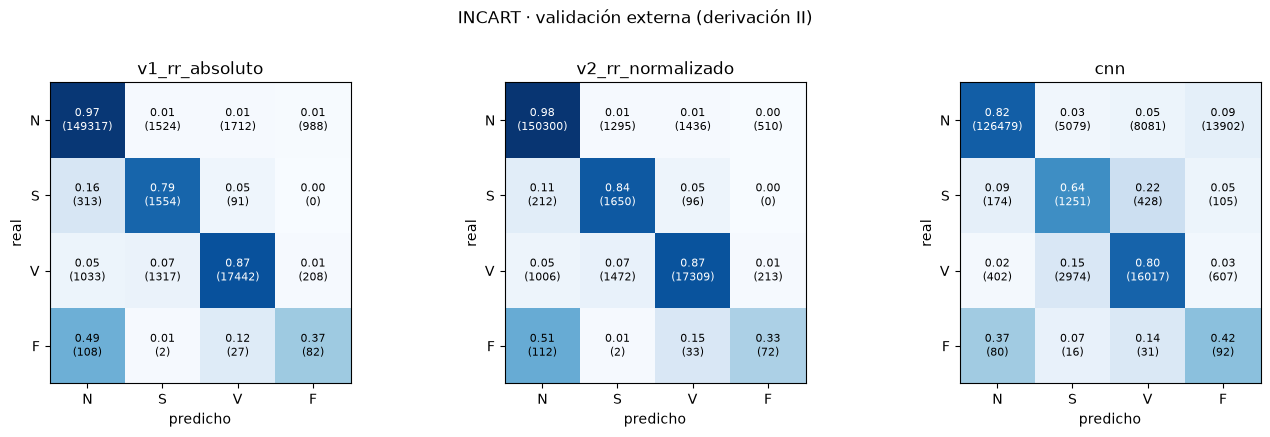

In [4]:
Image(str(FIG_DIR / "incart_confusion.png"))

**Conclusiones:**

- **v2 le gana a v1 en casi todas las métricas:** F1 macro **0.634 contra 0.617**, Se de S **0.843
  contra 0.794**, +P de V 0.917 contra 0.905 y F1 de N 0.985 contra 0.981. Es la comparación
  limpia que DS2 ya no podía dar.
- **Los dos modelos rinden mucho mejor acá que en DS2** (F1 macro 0.512), a pesar del cambio de
  derivación y de población. La explicación no es que INCART sea "más fácil", sino la
  **composición de pacientes**: en DS2 el 75 % de los latidos S venía de un único paciente
  bradicárdico, mientras que en INCART los S están repartidos. Es la misma lección de siempre en
  este proyecto, ahora en la otra dirección: **lo que domina la métrica es qué pacientes hay,
  no el modelo.**
- **La CNN vuelve a quedar última** (F1 macro 0.464), con 14 614 falsos F y 8 540 falsos V. Su
  problema de falsas alarmas se repite en las tres evaluaciones: es un defecto del modelo, no del
  conjunto de datos.
- La clase F sigue sin funcionar en ninguna versión (+P ≤ 0.09), como corresponde a algo aprendido
  de un solo paciente.

## 3. La hipótesis: ¿mejora v2 en pacientes con otra frecuencia cardíaca?

In [5]:
s_detection_by_heart_rate(incart, preds)

,pacientes,latidos_S,v1_rr_absoluto · S_Se,v1_rr_absoluto · S_+P,v2_rr_normalizado · S_Se,v2_rr_normalizado · S_+P,cnn · S_Se,cnn · S_+P
grupo,,,,,,,,
frecuencia como DS1,61,1889,0.803,0.408,0.851,0.403,0.627,0.170
fuera del rango de DS1,14,69,0.551,0.056,0.609,0.098,0.971,0.028


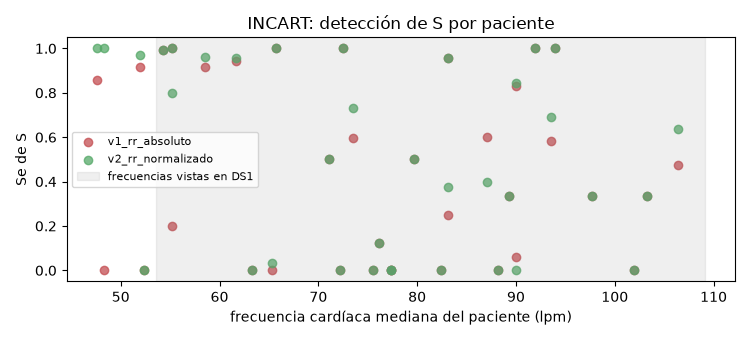

In [6]:
Image(str(FIG_DIR / "incart_s_by_heart_rate.png"))

**Conclusión: la hipótesis se sostiene, en los dos grupos.**

v2 detecta más S que v1 tanto en los pacientes con frecuencias como las de DS1 (0.851 contra
0.803) como en los que caen fuera de ese rango (0.609 contra 0.551). En el segundo grupo hay solo
**69 latidos S en 14 pacientes**, así que ese número por separado es muy ruidoso: la evidencia
fuerte es la del conjunto completo.

### 3.1 ¿La diferencia entre v1 y v2 es sólida?

Son los mismos 75 pacientes para los dos modelos, así que corresponde una comparación **pareada**.
La unidad de análisis correcta es el **paciente**, no el latido: los latidos de una misma persona
no son independientes.

In [7]:
from scipy.stats import binomtest, spearmanr, wilcoxon

from ecg.evaluate import per_record_metrics

V1, V2 = "v1_rr_absoluto", "v2_rr_normalizado"
por_paciente = pd.DataFrame({
    "lpm": hr["lpm"],
    "latidos": per_record_metrics(y, preds[V1], records)["latidos"],
    "err_v1": per_record_metrics(y, preds[V1], records)["errores"],
    "err_v2": per_record_metrics(y, preds[V2], records)["errores"],
})
por_paciente["diferencia"] = por_paciente.err_v2 - por_paciente.err_v1

gana_v2 = int((por_paciente.diferencia < 0).sum())
gana_v1 = int((por_paciente.diferencia > 0).sum())
w_err = wilcoxon(por_paciente.err_v1, por_paciente.err_v2)
rho, p_rho = spearmanr(por_paciente.lpm, por_paciente.diferencia)
correcto_v1, correcto_v2 = y == preds[V1], y == preds[V2]
solo_v2 = int((~correcto_v1 & correcto_v2).sum())
solo_v1 = int((correcto_v1 & ~correcto_v2).sum())

print(f"Errores totales: v1 {por_paciente.err_v1.sum()} · v2 {por_paciente.err_v2.sum()} "
      f"({100 * (por_paciente.err_v2.sum() / por_paciente.err_v1.sum() - 1):.1f} %)")
print(f"Pacientes donde gana v2: {gana_v2} · donde gana v1: {gana_v1} · empates: "
      f"{len(por_paciente) - gana_v2 - gana_v1}")
print(f"Suma de ganancias: {por_paciente[por_paciente.diferencia < 0].diferencia.sum()} · "
      f"suma de pérdidas: +{por_paciente[por_paciente.diferencia > 0].diferencia.sum()}")
print(f"Wilcoxon pareado sobre errores por paciente: p = {w_err.pvalue:.3f}")
print(f"McNemar por latido: v2 acierta y v1 no = {solo_v2}, al revés = {solo_v1}, "
      f"p = {binomtest(min(solo_v1, solo_v2), solo_v1 + solo_v2, 0.5).pvalue:.1e} "
      f"(los latidos NO son independientes: este p está inflado)")
print(f"Spearman frecuencia vs diferencia de errores: rho = {rho:.2f}, p = {p_rho:.3f}")

Errores totales: v1 7323 · v2 6387 (-12.8 %)
Pacientes donde gana v2: 34 · donde gana v1: 32 · empates: 9
Suma de ganancias: -2100 · suma de pérdidas: +1164
Wilcoxon pareado sobre errores por paciente: p = 0.749
McNemar por latido: v2 acierta y v1 no = 2637, al revés = 1701, p = 4.4e-46 (los latidos NO son independientes: este p está inflado)
Spearman frecuencia vs diferencia de errores: rho = -0.28, p = 0.013


In [8]:
display(por_paciente.nsmallest(5, "diferencia"))   # donde más gana v2
por_paciente.nlargest(5, "diferencia")             # donde más pierde v2

,lpm,latidos,err_v1,err_v2,diferencia
record,,,,,
12,91.9,2807,533,137,-396
10,122.7,3680,322,4,-318
5,56.8,1774,451,167,-284
16,50.5,1520,936,700,-236
36,135.0,3909,342,134,-208


,lpm,latidos,err_v1,err_v2,diferencia
record,,,,,
17,53.7,1671,209,392,183
39,53.5,1773,1,182,181
51,103.3,2775,19,118,99
72,76.1,2268,37,119,82
49,70.8,2145,16,97,81


**Conclusiones: la mejora es real en el agregado, pero no es pareja entre pacientes.**

- En total, v2 comete **6 387 errores contra 7 323 de v1: un 12.8 % menos.**
- Pero **paciente por paciente es casi un empate: v2 gana en 34, v1 en 32 y hay 9 empates.** La
  prueba de Wilcoxon pareada sobre los errores por paciente **no es significativa (p = 0.75)**.
- La mejora agregada viene de **ganancias grandes en pocos pacientes** (−2 100 errores en total)
  que superan a pérdidas más repartidas (+1 164).
- El McNemar por latido da p ≈ 4 × 10⁻⁴⁶, pero **ese número no vale**: los latidos de un mismo
  paciente no son independientes. Lo incluyo justamente para mostrar la diferencia entre un
  p-valor impresionante y uno honesto.
- **Un hallazgo que contradice mi expectativa:** la ventaja de v2 correlaciona con frecuencias
  **altas**, no bajas (Spearman rho = −0.28, p = 0.013). Yo esperaba lo contrario, porque el caso
  que motivó la v2 (registro 232) era bradicárdico. Mirándolo bien tiene sentido: normalizar ayuda
  cuando la frecuencia del paciente se aleja de la de entrenamiento **en cualquier dirección**. A
  135 lpm todos los intervalos son cortos, así que para v1 todos los latidos parecen prematuros.
  Los mayores ahorros están en pacientes de 92 a 135 lpm (registros 12, 10 y 36).
- En los 15 pacientes por debajo de 60 lpm, v2 solo gana en 5. La normalización **no es una
  garantía por paciente**.

## 4. Comparación con los otros conjuntos

In [9]:
cv1 = json.loads((config.REPORTS_DIR / "baseline_xgb_cv.json").read_text())["cv"]
cv2 = json.loads((config.REPORTS_DIR / "baseline_v2_cv.json").read_text())["cv"]
ds2 = json.loads((config.REPORTS_DIR / "ds2_results.json").read_text())["modelos"]["baseline_xgb"]
inc = {n: summary(y, p) for n, p in preds.items()}
METRICAS = ["macro_f1", "N_F1", "S_Se", "S_+P", "V_Se", "V_+P"]
pd.DataFrame({
    "v1 · CV DS1": {m: cv1[m] for m in METRICAS},
    "v1 · DS2": {m: ds2[m] for m in METRICAS},
    "v1 · INCART": {m: inc["v1_rr_absoluto"][m] for m in METRICAS},
    "v2 · CV DS1": {m: cv2[m] for m in METRICAS},
    "v2 · INCART": {m: inc["v2_rr_normalizado"][m] for m in METRICAS},
}).round(3)

,v1 · CV DS1,v1 · DS2,v1 · INCART,v2 · CV DS1,v2 · INCART
macro_f1,0.493,0.512,0.617,0.487,0.634
N_F1,0.947,0.933,0.981,0.939,0.985
S_Se,0.319,0.155,0.794,0.370,0.843
S_+P,0.445,0.221,0.353,0.367,0.373
V_Se,0.914,0.964,0.872,0.910,0.865
V_+P,0.509,0.852,0.905,0.480,0.917


**Conclusiones:**

- **Cada conjunto da una película distinta de la misma pareja de modelos**, y la diferencia entre
  ellos es mucho mayor que la diferencia entre modelos. La Se de S de v1 va de 0.32 (validación)
  a 0.16 (DS2) y a 0.79 (INCART).
- Eso **no** significa que las métricas no sirvan: significa que **una métrica sin decir sobre qué
  pacientes se calculó no informa nada**. Es el argumento central del proyecto, ahora con tres
  conjuntos.
- La comparación válida entre v1 y v2 es la de la columna de INCART, porque es la única donde
  ninguna de las dos versiones influyó en el diseño.

## 5. Errores por paciente

In [10]:
from ecg.evaluate import per_record_metrics

err = pd.DataFrame({n: per_record_metrics(y, p, records)["errores"] for n, p in preds.items()})
err["latidos"] = per_record_metrics(y, preds["v1_rr_absoluto"], records)["latidos"]
err["lpm"] = hr["lpm"]
err["% error v1"] = (100 * err["v1_rr_absoluto"] / err["latidos"]).round(1)
err["% error v2"] = (100 * err["v2_rr_normalizado"] / err["latidos"]).round(1)
display(err.sort_values("v1_rr_absoluto", ascending=False).head(8))
print("Pacientes donde v2 comete menos errores que v1:",
      int((err["v2_rr_normalizado"] < err["v1_rr_absoluto"]).sum()), "de", len(err))

,v1_rr_absoluto,v2_rr_normalizado,cnn,latidos,lpm,% error v1,% error v2
record,,,,,,,
16,936,700,464,1520,50.5,61.6,46.1
19,729,689,879,2060,73.0,35.4,33.4
12,533,137,643,2807,91.9,19.0,4.9
62,469,483,432,2267,77.4,20.7,21.3
5,451,167,1484,1774,56.8,25.4,9.4
36,342,134,1158,3909,135.0,8.7,3.4
10,322,4,729,3680,122.7,8.8,0.1
31,289,256,899,3207,116.8,9.0,8.0


Pacientes donde v2 comete menos errores que v1: 34 de 75


In [11]:
sym = pd.DataFrame({"símbolo": incart["symbol"], "real": y,
                    "v1": preds["v1_rr_absoluto"], "v2": preds["v2_rr_normalizado"]})
(sym.assign(ok_v1=sym.real == sym.v1, ok_v2=sym.real == sym.v2)
    .groupby(["real", "símbolo"]).agg(latidos=("ok_v1", "size"), Se_v1=("ok_v1", "mean"),
                                      Se_v2=("ok_v2", "mean")).round(3))

latidos  Se_v1  Se_v2
real símbolo                       
F    F            219  0.374  0.329
N    N         150279  0.979  0.986
     R           3170  0.648  0.664
     j             92  1.000  1.000
S    A           1942  0.798  0.848
     S             16  0.250  0.250
V    V          20000  0.872  0.865

**Conclusiones:**

- Los errores se concentran en pocos pacientes, igual que en MIT-BIH: los 8 peores explican una
  parte enorme del total.
- Por símbolo original se ve que el problema de siempre sigue: los latidos auriculares prematuros
  aberrados y los de fusión son los más difíciles, y las clases N y V se sostienen bien incluso
  con la derivación cambiada.

## Resumen de la validación externa

**Lo que se puede afirmar ahora, y no se podía antes:**

| | v1 (RR absoluto) | v2 (RR normalizado) |
|---|---|---|
| F1 macro | 0.617 | **0.634** |
| Se de S | 0.794 | **0.843** |
| +P de V | 0.905 | **0.917** |
| Errores totales | 7 323 | **6 387 (−12.8 %)** |

1. **v2 es mejor que v1 en pacientes que ninguna de las dos versiones influyó.** Es la evidencia
   que DS2 ya no podía dar, y respalda usar v2 como modelo por defecto de la API.
2. **Con la honestidad que corresponde:** la ventaja no es uniforme (gana en 34 de 75 pacientes) y
   la prueba pareada por paciente no alcanza significancia (p = 0.75). La mejora agregada viene de
   ganancias grandes en pacientes con frecuencias alejadas de las de entrenamiento.
3. **La hipótesis original era incompleta.** Pensábamos en pacientes lentos (el registro 232); la
   evidencia dice que el beneficio aparece sobre todo en pacientes **rápidos**. El mecanismo
   —depender de la frecuencia basal— es el mismo, pero actúa en las dos direcciones.
4. **La CNN queda descartada** para producción: peor en DS1, en DS2 y en INCART, siempre por
   falsas alarmas.
5. **La clase F no funciona en ningún conjunto.** Corresponde declararla fuera del alcance en el
   uso previsto (Fase 7) o reportarla junto con V.

**Lo que sigue pendiente:** INCART usa derivación II y no MLII, así que parte de la degradación
respecto de MIT-BIH es atribuible a eso y no se puede separar sin un experimento específico.